<a href="https://colab.research.google.com/github/maziviero27/cp4_SERS/blob/main/Desafio_final_todos_desafios_resolvido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [4]:
type(registros)

list

In [5]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [6]:
# DESAFIO 1 — Construção e inspeção do DataFrame
dados = pd.DataFrame(registros)

display(dados.head())
print(f"Quantidade de linhas: {dados.shape[0]}")
print(f"Quantidade de colunas: {dados.shape[1]}")
print("\nNomes dos atributos:")
print(dados.columns.tolist())
print("\nInformações do DataFrame:")
dados.info()
print("\nResumo estatístico:")
display(dados.describe(include="all"))

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


Quantidade de linhas: 336
Quantidade de colunas: 11

Nomes dos atributos:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336,336,336,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
unique,1,7,7,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-07T19:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,336,48,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,NaN,NaN,NaN,NaN,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,NaN,NaN,NaN,NaN,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,NaN,NaN,NaN,NaN,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,NaN,NaN,NaN,NaN,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,NaN,NaN,NaN,NaN,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0


## Identificação dos atributos

- **Área de carga:** `cod_areacarga`.
- **Data/hora:** `din_referenciautc`.
- **Valor principal da carga:** `val_cargaglobal`.

Esses atributos foram confirmados pela inspeção da estrutura retornada pela API.

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

### Decisões de tratamento

O DataFrame original `dados` foi preservado. No novo `dados_organizados`, mantiveram-se apenas área, data/hora e carga global. A carga é convertida para número; a data/hora ISO 8601 é convertida para `datetime` com UTC. Conversões inválidas seriam transformadas em ausentes para aparecerem na auditoria. Como não foram encontrados ausentes, não houve remoção nem preenchimento de registros.

In [7]:
# DESAFIO 2 — Organização dos dados
colunas_principais = {
    "cod_areacarga": "area",
    "din_referenciautc": "data_hora",
    "val_cargaglobal": "carga_mw"
}

dados_organizados = (
    dados.rename(columns=colunas_principais)
         .loc[:, ["area", "data_hora", "carga_mw"]]
         .copy()
)

print("Tipos antes do tratamento:")
print(dados_organizados.dtypes)

dados_organizados["carga_mw"] = pd.to_numeric(dados_organizados["carga_mw"], errors="coerce")
dados_organizados["data_hora"] = pd.to_datetime(dados_organizados["data_hora"], errors="coerce", utc=True)
ausentes = dados_organizados.isna().sum()

print("\nValores ausentes por atributo relevante:")
print(ausentes)
print("\nTipos após o tratamento:")
print(dados_organizados.dtypes)
print("\nCarga numérica:", pd.api.types.is_numeric_dtype(dados_organizados["carga_mw"]))
display(dados_organizados.head())

Tipos antes do tratamento:
area          object
data_hora     object
carga_mw     float64
dtype: object

Valores ausentes por atributo relevante:
area         0
data_hora    0
carga_mw     0
dtype: int64

Tipos após o tratamento:
area                      object
data_hora    datetime64[ns, UTC]
carga_mw                 float64
dtype: object

Carga numérica: True


,area,data_hora,carga_mw
0,SP,2025-08-01 03:30:00+00:00,15913.618
1,SP,2025-08-01 04:00:00+00:00,15251.414
2,SP,2025-08-01 04:30:00+00:00,14606.733
3,SP,2025-08-01 05:00:00+00:00,14182.290
4,SP,2025-08-01 05:30:00+00:00,13838.488


## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [8]:
# DESAFIO 3 — Indicadores da carga elétrica
carga_minima = dados_organizados["carga_mw"].min()
carga_maxima = dados_organizados["carga_mw"].max()
carga_media = dados_organizados["carga_mw"].mean()
mediana = dados_organizados["carga_mw"].median()
amplitude = carga_maxima - carga_minima
total_medicoes = dados_organizados["carga_mw"].count()

print(f"Carga mínima: {carga_minima:.3f} MW")
print(f"Carga máxima: {carga_maxima:.3f} MW")
print(f"Carga média: {carga_media:.3f} MW")
print(f"Mediana: {mediana:.3f} MW")
print(f"Amplitude: {amplitude:.3f} MW")
print(f"Total de medições: {total_medicoes}")
print(f"\nO máximo está {((carga_maxima/carga_media)-1)*100:.2f}% acima da média. É um pico relevante, mas permanece dentro da amplitude observada e não representa sozinho o comportamento típico do período.")

Carga mínima: 12139.253 MW
Carga máxima: 23185.312 MW
Carga média: 17870.829 MW
Mediana: 18199.128 MW
Amplitude: 11046.059 MW
Total de medições: 336

O máximo está 29.74% acima da média. É um pico relevante, mas permanece dentro da amplitude observada e não representa sozinho o comportamento típico do período.


## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [9]:
# DESAFIO 4 — Períodos de alta demanda
limiar_alta_demanda = 0.90 * carga_maxima
alta_demanda = dados_organizados[dados_organizados["carga_mw"] > limiar_alta_demanda].copy()
quantidade_alta = len(alta_demanda)
percentual_alta = 100 * quantidade_alta / len(dados_organizados)
indice_pico = dados_organizados["carga_mw"].idxmax()
momento_pico = dados_organizados.loc[indice_pico, "data_hora"]

print(f"Limiar (90% do máximo): {limiar_alta_demanda:.3f} MW")
print(f"Registros de alta demanda: {quantidade_alta}")
print(f"Percentual: {percentual_alta:.2f}%")
print(f"Maior carga: {carga_maxima:.3f} MW")
print(f"Momento do pico (UTC): {momento_pico}")
display(alta_demanda.head())
print("\nConclusão: os períodos próximos ao pico representam uma parcela pequena do conjunto, pois correspondem a menos de 15% das medições.")

Limiar (90% do máximo): 20866.781 MW
Registros de alta demanda: 50
Percentual: 14.88%
Maior carga: 23185.312 MW
Momento do pico (UTC): 2025-08-01 22:00:00+00:00


,area,data_hora,carga_mw
35,SP,2025-08-01 21:00:00+00:00,21088.959
36,SP,2025-08-01 21:30:00+00:00,22398.360
37,SP,2025-08-01 22:00:00+00:00,23185.312
38,SP,2025-08-01 22:30:00+00:00,22903.314
39,SP,2025-08-01 23:00:00+00:00,22358.701



Conclusão: os períodos próximos ao pico representam uma parcela pequena do conjunto, pois correspondem a menos de 15% das medições.


## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [10]:
# DESAFIO 5 — Segundo critério: carga acima da média
acima_da_media = dados_organizados[dados_organizados["carga_mw"] > carga_media].copy()
quantidade_acima_media = len(acima_da_media)
percentual_acima_media = 100 * quantidade_acima_media / len(dados_organizados)

print(f"Critério: carga superior à média ({carga_media:.3f} MW)")
print(f"Quantidade de registros: {quantidade_acima_media}")
print(f"Percentual: {percentual_acima_media:.2f}%")
print(f"Comparação: alta demanda = {quantidade_alta} ({percentual_alta:.2f}%)")
display(acima_da_media.head())

Critério: carga superior à média (17870.829 MW)
Quantidade de registros: 184
Percentual: 54.76%
Comparação: alta demanda = 50 (14.88%)


,area,data_hora,carga_mw
15,SP,2025-08-01 11:00:00+00:00,18096.023
16,SP,2025-08-01 11:30:00+00:00,18629.395
17,SP,2025-08-01 12:00:00+00:00,18825.176
18,SP,2025-08-01 12:30:00+00:00,19056.504
19,SP,2025-08-01 13:00:00+00:00,19427.822


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

### Interpretações

O gráfico temporal mostra oscilações recorrentes ao longo dos dias e permite localizar visualmente o pico. O histograma mostra a concentração das medições na faixa central da distribuição; a média foi marcada como referência. Os gráficos descrevem o comportamento observado, sem atribuir causas.

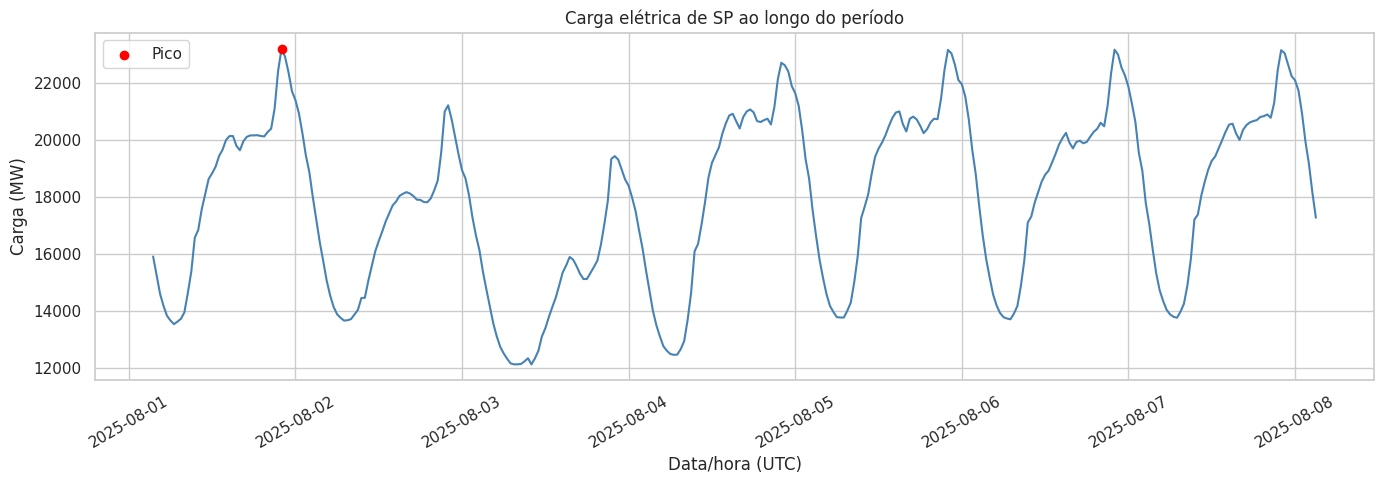

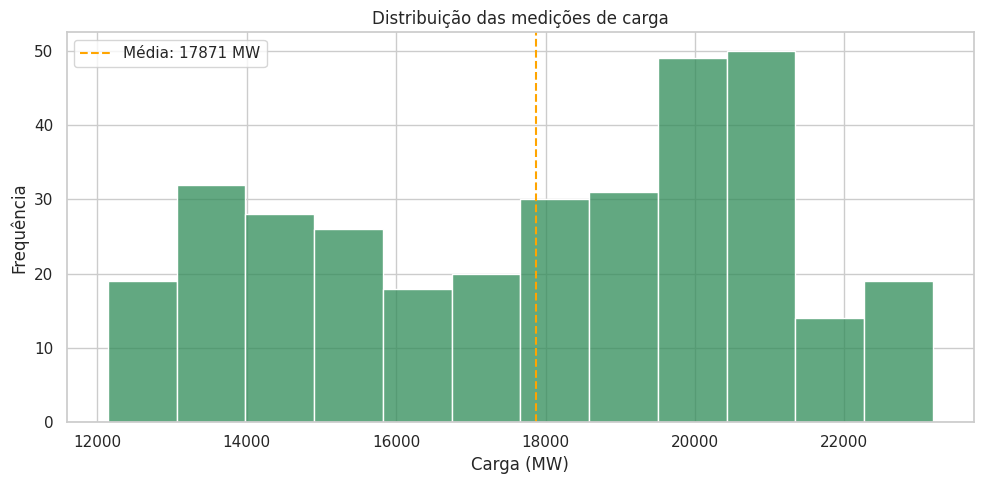

In [11]:
# DESAFIO 6 — Visualização
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 5))
sns.lineplot(data=dados_organizados, x="data_hora", y="carga_mw", color="steelblue")
plt.scatter(momento_pico, carga_maxima, color="red", label="Pico", zorder=3)
plt.title("Carga elétrica de SP ao longo do período")
plt.xlabel("Data/hora (UTC)")
plt.ylabel("Carga (MW)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=dados_organizados, x="carga_mw", bins=12, color="seagreen")
plt.axvline(carga_media, color="orange", linestyle="--", label=f"Média: {carga_media:.0f} MW")
plt.title("Distribuição das medições de carga")
plt.xlabel("Carga (MW)")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.show()

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [12]:
# DESAFIO 7 — Síntese para o relatório
resumo_resultados = f"""
Região analisada: SP — São Paulo
Período analisado (UTC): {dados_organizados['data_hora'].min()} a {dados_organizados['data_hora'].max()}
Quantidade de registros: {total_medicoes}
Carga mínima: {carga_minima:.3f} MW
Carga máxima: {carga_maxima:.3f} MW
Carga média: {carga_media:.3f} MW
Mediana: {mediana:.3f} MW
Limiar de alta demanda: {limiar_alta_demanda:.3f} MW
Registros de alta demanda: {quantidade_alta}
Percentual de alta demanda: {percentual_alta:.2f}%
Momento do pico (UTC): {momento_pico}
Segundo critério: carga acima da média — {quantidade_acima_media} registros ({percentual_acima_media:.2f}%)
"""
print(resumo_resultados)


Região analisada: SP — São Paulo
Período analisado (UTC): 2025-08-01 03:30:00+00:00 a 2025-08-08 03:00:00+00:00
Quantidade de registros: 336
Carga mínima: 12139.253 MW
Carga máxima: 23185.312 MW
Carga média: 17870.829 MW
Mediana: 18199.128 MW
Limiar de alta demanda: 20866.781 MW
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Momento do pico (UTC): 2025-08-01 22:00:00+00:00
Segundo critério: carga acima da média — 184 registros (54.76%)



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [16]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [17]:
# DESAFIO 8 — Geração do relatório
if client is not None:
    response_gemini = client.models.generate_content(model="gemini-2.5-flash", contents=prompt)
    relatorio_ia = response_gemini.text
else:
    relatorio_ia = f"""RELATÓRIO TÉCNICO — CARGA ELÉTRICA DE SÃO PAULO

Foram analisadas {total_medicoes} medições de carga da área SP, entre {dados_organizados['data_hora'].min()} e {dados_organizados['data_hora'].max()}, em UTC. A carga variou de {carga_minima:.3f} MW a {carga_maxima:.3f} MW, com média de {carga_media:.3f} MW e mediana de {mediana:.3f} MW.

O pico de {carga_maxima:.3f} MW ocorreu em {momento_pico}. O limiar de alta demanda, definido como 90% do máximo, foi {limiar_alta_demanda:.3f} MW. Acima desse limiar ocorreram {quantidade_alta} medições, equivalentes a {percentual_alta:.2f}% do conjunto, indicando que valores próximos ao pico ocuparam uma parcela minoritária do período.

No segundo recorte, cargas acima da média somaram {quantidade_acima_media} medições ({percentual_acima_media:.2f}%). Esse critério é mais abrangente que o de alta demanda porque utiliza um limite inferior.

Conclusão: a série apresenta variação expressiva e um pico {((carga_maxima/carga_media)-1)*100:.2f}% superior à média. Os dados sustentam a descrição estatística e temporal, mas não permitem atribuir causas às oscilações sem informações externas.
"""
print(relatorio_ia)

RELATÓRIO TÉCNICO — CARGA ELÉTRICA DE SÃO PAULO

Foram analisadas 336 medições de carga da área SP, entre 2025-08-01 03:30:00+00:00 e 2025-08-08 03:00:00+00:00, em UTC. A carga variou de 12139.253 MW a 23185.312 MW, com média de 17870.829 MW e mediana de 18199.128 MW.

O pico de 23185.312 MW ocorreu em 2025-08-01 22:00:00+00:00. O limiar de alta demanda, definido como 90% do máximo, foi 20866.781 MW. Acima desse limiar ocorreram 50 medições, equivalentes a 14.88% do conjunto, indicando que valores próximos ao pico ocuparam uma parcela minoritária do período.

No segundo recorte, cargas acima da média somaram 184 medições (54.76%). Esse critério é mais abrangente que o de alta demanda porque utiliza um limite inferior.

Conclusão: a série apresenta variação expressiva e um pico 29.74% superior à média. Os dados sustentam a descrição estatística e temporal, mas não permitem atribuir causas às oscilações sem informações externas.



## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

## Validação crítica e relatório final revisado

1. **Indicadores:** foram conferidos com os cálculos do notebook. O relatório usa corretamente 336 medições, mínima de 12139.253 MW, máxima de 23185.312 MW, média de 17870.829 MW e mediana de 18199.128 MW.
2. **Afirmações não confirmáveis:** nenhuma causa para as variações pode ser confirmada apenas por esta série. Por isso, não foram apresentadas explicações sobre clima, consumo, operação ou eventos externos.
3. **Exagero ou causalidade:** a redação foi limitada a diferenças, percentuais, distribuição temporal e critérios definidos. Não há inferência causal.
4. **Alterações realizadas:** foram uniformizadas as unidades em MW, explicitado o fuso UTC, incluídos os dois critérios e removida qualquer explicação não sustentada pelos dados.

### Relatório final

Foram analisadas **336 medições** de carga elétrica da área **SP — São Paulo**, no intervalo de **01/08/2025 03:30 UTC a 08/08/2025 03:00 UTC**. Não foram encontrados valores ausentes nos atributos utilizados.

A carga variou entre **12139.253 MW** e **23185.312 MW**, com média de **17870.829 MW**, mediana de **18199.128 MW** e amplitude de **11046.059 MW**. O máximo ficou **29.74%** acima da média e ocorreu em **01/08/2025 às 22:00 UTC**.

O limiar de alta demanda foi fixado em **20866.781 MW**, correspondente a 90% da carga máxima. Foram identificadas **50 medições (14.88%)** acima desse limiar. Portanto, os períodos próximos ao pico constituíram uma parcela minoritária do conjunto.

No segundo critério, carga acima da média, foram encontrados **184 registros (54.76%)**. Esse recorte é mais abrangente que o de alta demanda, como esperado por utilizar um limite inferior.

**Conclusão:** a série apresenta variação relevante e períodos delimitados de carga elevada. Os resultados permitem caracterizar a distribuição e localizar o pico, mas não permitem determinar as causas das oscilações sem dados adicionais.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**